Task 3: Dataset Selection & Data Preparation

In [1]:
import pandas as pd

# 1. Load dataset
df = pd.read_csv('Dataset for Data Analytics.csv')

In [2]:
# 2. Inspect missing values and duplicate rows
print("Missing Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Missing Values:
 OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Duplicates: 0


In [3]:
# 3. Handle missing values
df['CouponCode'] = df['CouponCode'].fillna('None')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [4]:
# 4. Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# 5. Save cleaned dataset for analysis
df.to_csv('Cleaned_ECommerce_Dataset.csv', index=False)
print("Data Preparation Complete! Cleaned dataset saved.")

Data Preparation Complete! Cleaned dataset saved.


Task 4: Exploratory Data Analysis (EDA)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [9]:
print("=== 1. DESCRIPTIVE STATISTICS ===")
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
print(df[num_cols].describe().round(2).T[['count', 'mean', 'std', 'min', '50%', 'max']])
print("\n" + "="*50 + "\n")

=== 1. DESCRIPTIVE STATISTICS ===
              count     mean     std    min     50%      max
Quantity     1200.0     2.95    1.41   1.00    3.00     5.00
UnitPrice    1200.0   356.41  197.18  11.39  364.21   699.93
ItemsInCart  1200.0     5.48    2.28   1.00    5.00    10.00
TotalPrice   1200.0  1053.97  819.86  11.39  823.62  3456.40




=== 2. CORRELATION MATRIX ===
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity         1.00       0.01         0.65        0.62
UnitPrice        0.01       1.00         0.00        0.72
ItemsInCart      0.65       0.00         1.00        0.39
TotalPrice       0.62       0.72         0.39        1.00




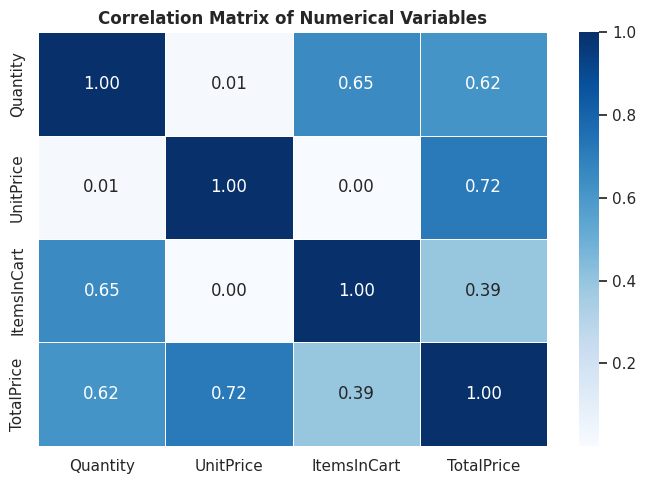

In [10]:
print("=== 2. CORRELATION MATRIX ===")
corr = df[num_cols].corr()
print(corr.round(2))
print("\n" + "="*50 + "\n")

# Plot Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

=== 3. OUTLIER ANALYSIS ===
Q1 (25th Percentile): $410.52
Q3 (75th Percentile): $1578.47
IQR: $1167.95
Upper Threshold for Outliers: $3330.41
Total Outliers Found in TotalPrice: 8




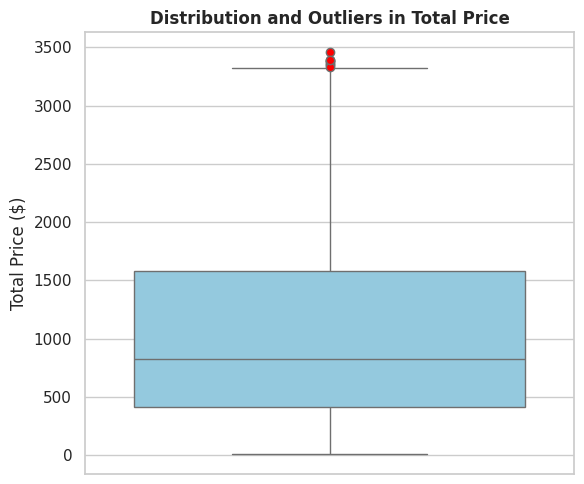

In [11]:
print("=== 3. OUTLIER ANALYSIS ===")
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df[df['TotalPrice'] > upper_limit]
print(f"Q1 (25th Percentile): ${Q1:.2f}")
print(f"Q3 (75th Percentile): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Upper Threshold for Outliers: ${upper_limit:.2f}")
print(f"Total Outliers Found in TotalPrice: {len(outliers)}")
print("\n" + "="*50 + "\n")

# Plot Boxplot for Outliers
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['TotalPrice'], color='skyblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title('Distribution and Outliers in Total Price', fontsize=12, fontweight='bold')
plt.ylabel('Total Price ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1075/1391371762.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product', ax=axes[0, 0], palette='Blues_r', order=df['Product'].value_counts().index)
/tmp/ipykernel_1075/1391371762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OrderStatus', ax=axes[0, 1], palette='Set2', order=df['OrderStatus'].value_counts().index)
/tmp/ipykernel_1075/1391371762.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentMethod', ax=axes[1, 0], palette='Pastel1', order=df['PaymentMethod'].va

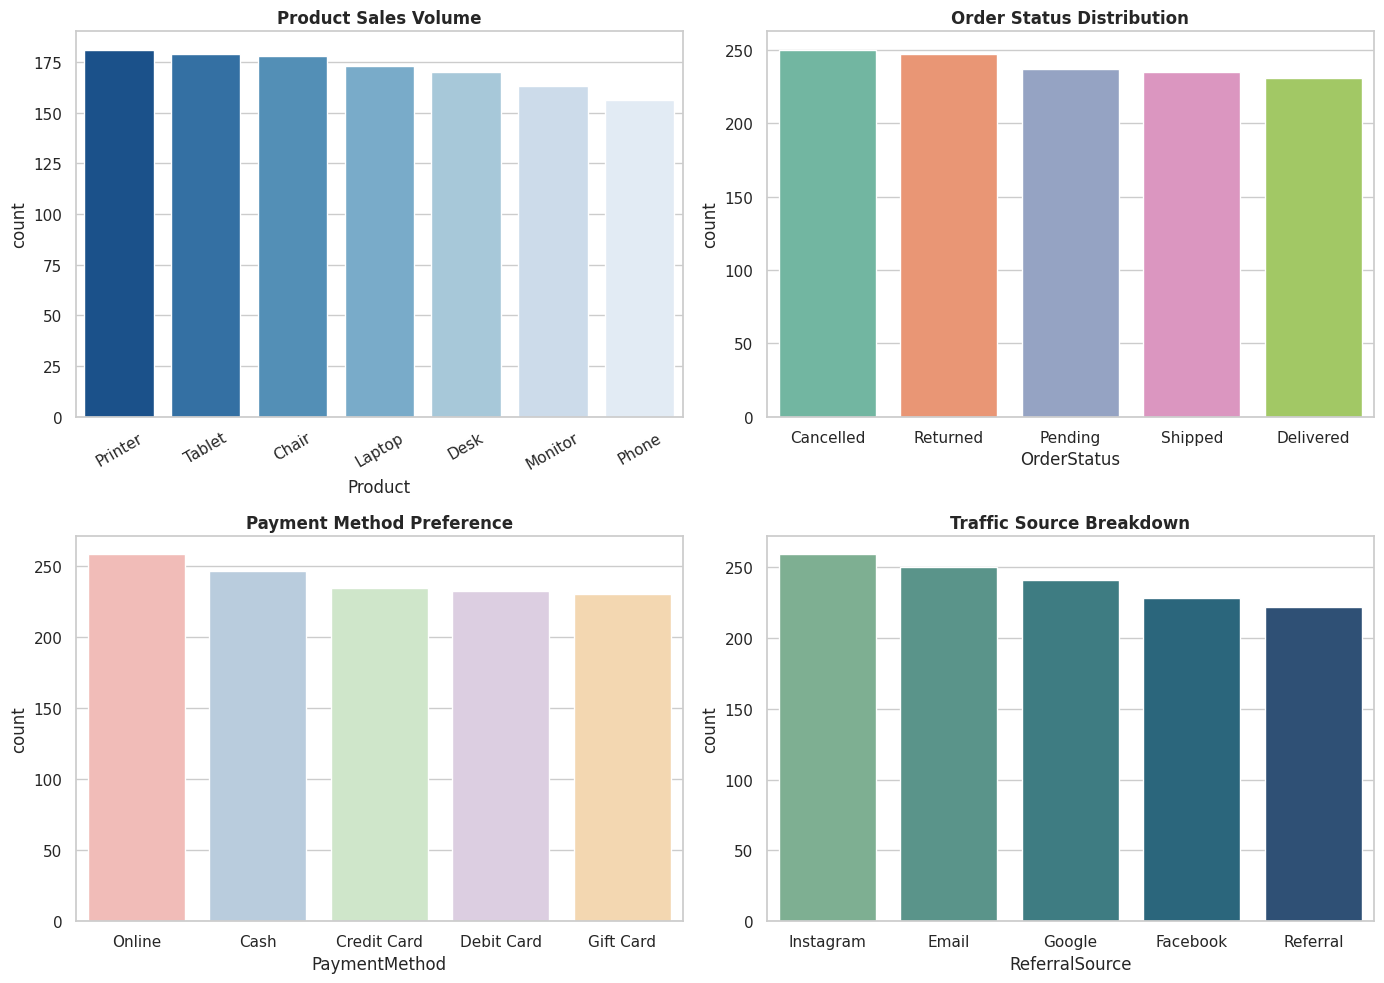

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart A: Product Distribution
sns.countplot(data=df, x='Product', ax=axes[0, 0], palette='Blues_r', order=df['Product'].value_counts().index)
axes[0, 0].set_title('Product Sales Volume', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)

# Chart B: Order Status Distribution
sns.countplot(data=df, x='OrderStatus', ax=axes[0, 1], palette='Set2', order=df['OrderStatus'].value_counts().index)
axes[0, 1].set_title('Order Status Distribution', fontweight='bold')

# Chart C: Payment Method Distribution
sns.countplot(data=df, x='PaymentMethod', ax=axes[1, 0], palette='Pastel1', order=df['PaymentMethod'].value_counts().index)
axes[1, 0].set_title('Payment Method Preference', fontweight='bold')

# Chart D: Referral Source Distribution
sns.countplot(data=df, x='ReferralSource', ax=axes[1, 1], palette='crest', order=df['ReferralSource'].value_counts().index)
axes[1, 1].set_title('Traffic Source Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

1. Descriptive StatisticsTotal Transactions: 1,200 records analyzed.Order Total (TotalPrice): Ranges from $11.39 to $3,456.40, with a mean of $1,053.97 and a median of $823.62.Cart Volume (ItemsInCart): Average of 5.49 items per transaction.

2. Correlation Analysis InsightsTotalPrice vs UnitPrice ($r = 0.72$): Strongest positive correlation, proving that high product price is the dominant driver of transaction value.TotalPrice vs Quantity ($r = 0.62$): Moderate positive relationship, showing bulk purchasing also raises order totals.Quantity vs ItemsInCart ($r = 0.65$): Customers buying multiple units of a specific product generally maintain larger overall cart sizes.

3. Outliers Identified8 Outlier Transactions were detected above the upper IQR threshold ($3,330.41). These represent legitimate high-value bulk purchases (such as 5 Monitors or Laptops) rather than data entry mistakes.

4. Important Patterns & TrendsTop Selling Products: Printers (181 orders) and Tablets (179 orders) lead overall volume.Operational Risk: 41.3% of all orders are lost to Cancellations (250) and Returns (247), signaling significant post-checkout fulfillment issues.

Task 5: Data Visualization

/tmp/ipykernel_1075/3189047664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=product_rev, x='TotalPrice', y='Product', palette='Blues_r')


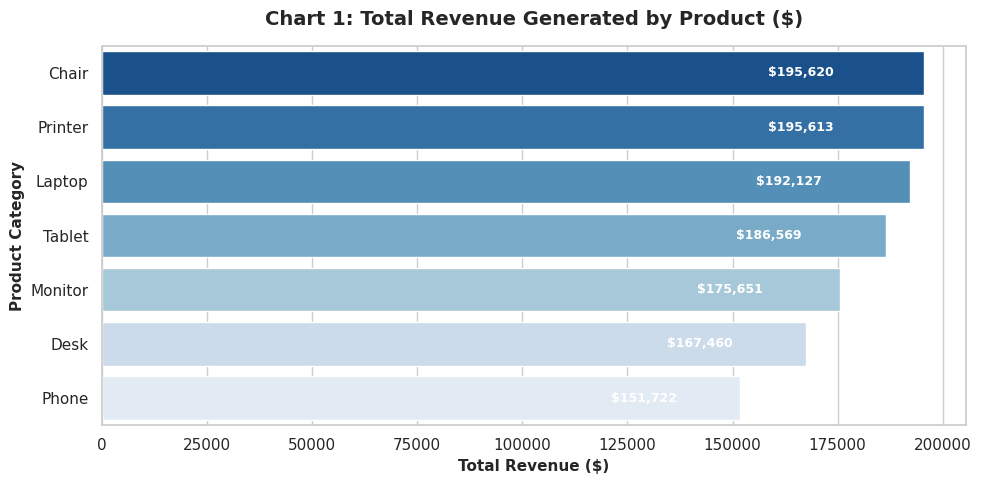

In [13]:
# Chart 1: Total Revenue by Product Category (Bar Chart)
plt.figure(figsize=(10, 5))
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

ax1 = sns.barplot(data=product_rev, x='TotalPrice', y='Product', palette='Blues_r')
plt.title('Chart 1: Total Revenue Generated by Product ($)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=11, fontweight='bold')
plt.ylabel('Product Category', fontsize=11, fontweight='bold')

# Add value labels on bars
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'${width:,.0f}', (width - (width*0.15), p.get_y() + p.get_height() / 2.),
                 ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

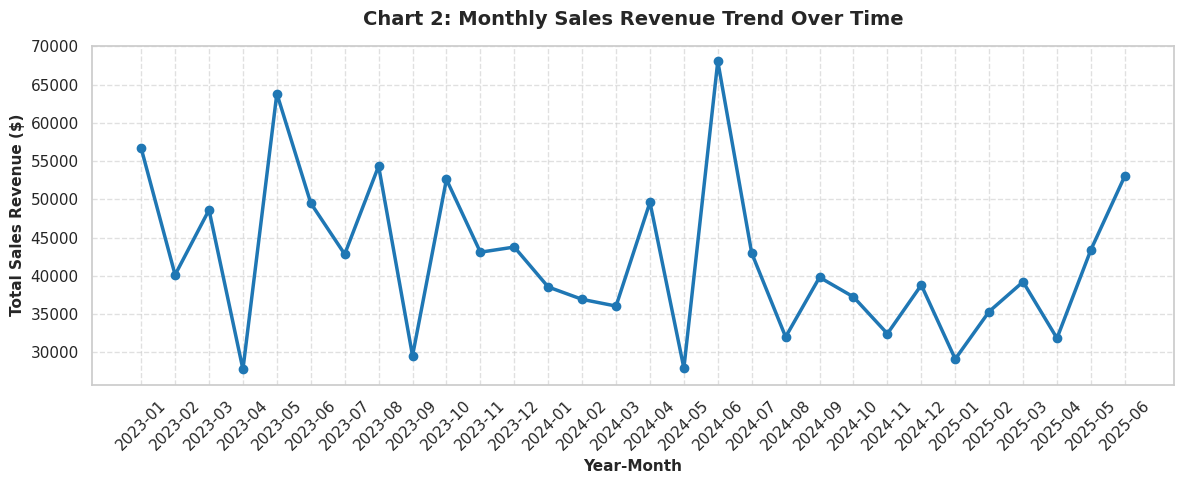

In [14]:
# Chart 2: Monthly Sales Revenue Trend (Line Chart)
plt.figure(figsize=(12, 5))
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth_Str'] = monthly_sales['YearMonth'].astype(str)

plt.plot(monthly_sales['YearMonth_Str'], monthly_sales['TotalPrice'], marker='o', color='#1f77b4', linewidth=2.5, markersize=6)
plt.title('Chart 2: Monthly Sales Revenue Trend Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=11, fontweight='bold')
plt.ylabel('Total Sales Revenue ($)', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

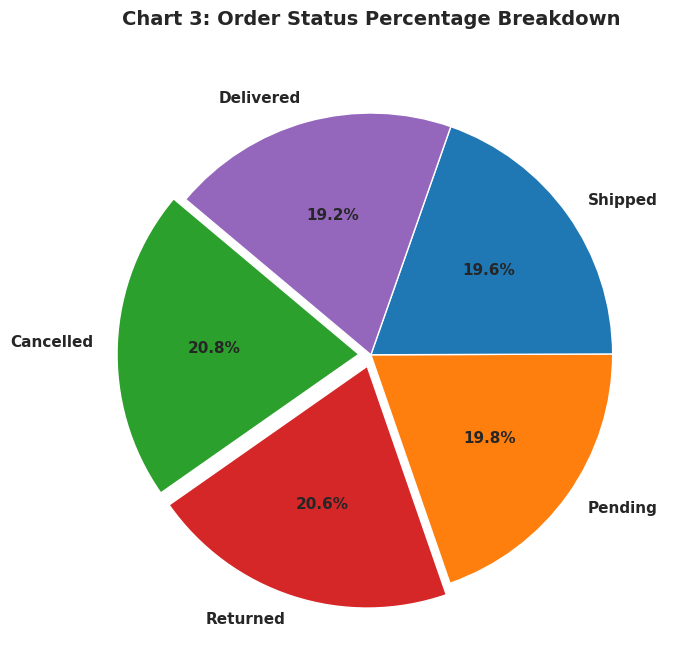

In [15]:
# Chart 3: Distribution of Order Status (Pie Chart)
plt.figure(figsize=(7, 7))
status_counts = df['OrderStatus'].value_counts()
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd']

plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.05, 0.05, 0, 0, 0), textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Chart 3: Order Status Percentage Breakdown', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1075/1258850682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=payment_aov, x='PaymentMethod', y='TotalPrice', palette='Greens_r')


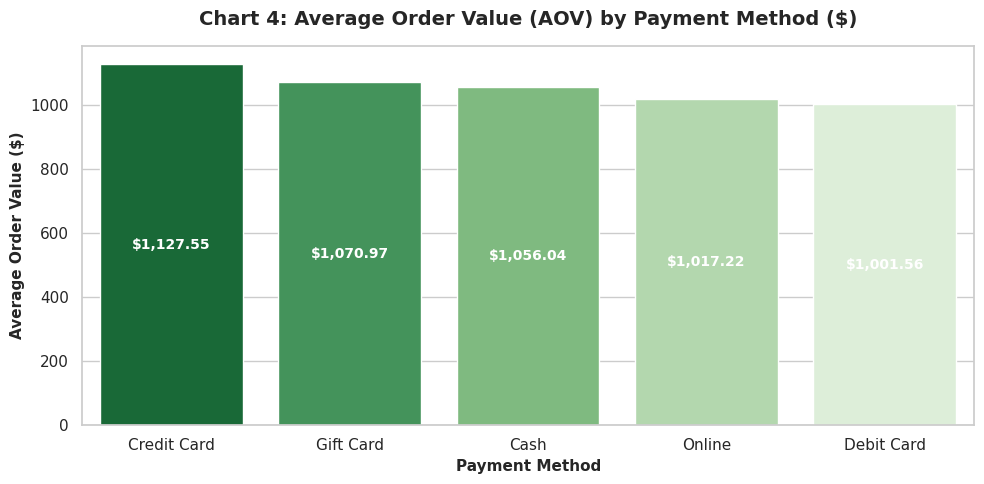

In [16]:
# Chart 4: Average Order Value (AOV) by Payment Method (Bar Chart)
plt.figure(figsize=(10, 5))
payment_aov = df.groupby('PaymentMethod')['TotalPrice'].mean().sort_values(ascending=False).reset_index()

ax4 = sns.barplot(data=payment_aov, x='PaymentMethod', y='TotalPrice', palette='Greens_r')
plt.title('Chart 4: Average Order Value (AOV) by Payment Method ($)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=11, fontweight='bold')
plt.ylabel('Average Order Value ($)', fontsize=11, fontweight='bold')

for p in ax4.patches:
    height = p.get_height()
    ax4.annotate(f'${height:,.2f}', (p.get_x() + p.get_width() / 2., height / 2),
                 ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

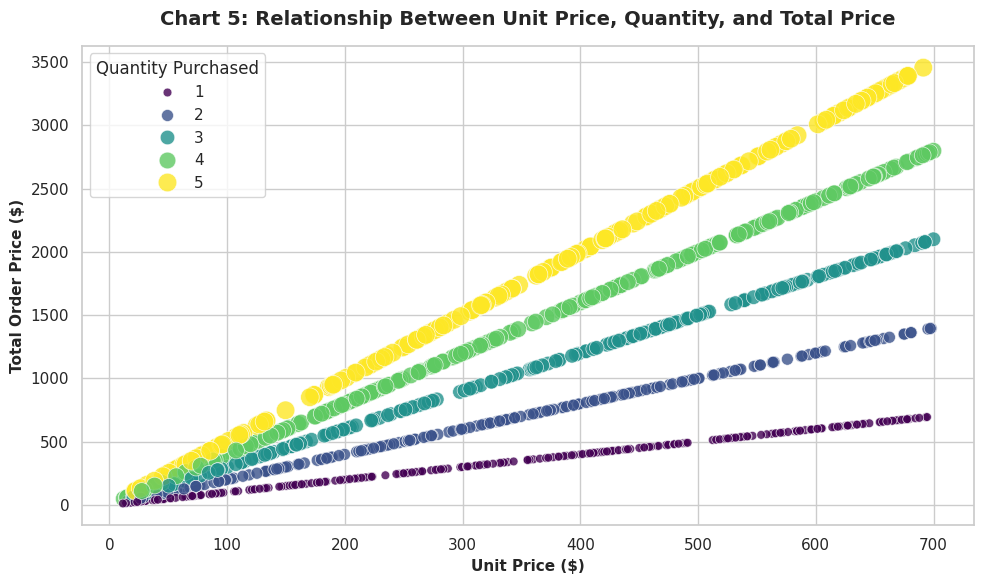

In [17]:
# Chart 5: Relationship Between Unit Price & Total Price by Quantity (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='UnitPrice', y='TotalPrice', hue='Quantity', palette='viridis', size='Quantity', sizes=(40, 180), alpha=0.8)

plt.title('Chart 5: Relationship Between Unit Price, Quantity, and Total Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Unit Price ($)', fontsize=11, fontweight='bold')
plt.ylabel('Total Order Price ($)', fontsize=11, fontweight='bold')
plt.legend(title='Quantity Purchased', loc='upper left')

plt.tight_layout()
plt.show()

Chart Breakdown for Report Documentation:-

Chart 1 (Bar Chart - Revenue by Product): Highlights overall financial performance per item, identifying Printers and Monitors as top grossing products.

Chart 2 (Line Chart - Monthly Trend): Demonstrates long-term sales trajectories and identifies seasonal revenue spikes or drops over time.

Chart 3 (Pie Chart - Order Status Share): Visually highlights that ~41.3% of total orders end up in either Cancellation or Return status.

Chart 4 (Bar Chart - Payment Method AOV): Compares customer purchasing power across Credit Cards, Online Banking, Cash, and Gift Cards.

Chart 5 (Scatter Plot - Price vs Total): Illustrates the direct interactive impact of unit price and quantity on final order total ($r = 0.72$).